# 🏠 Airbnb Marketplace Intelligence | SQL Analytics

An end-to-end SQL analytics project that explores Airbnb marketplace performance by analyzing supply, demand, pricing, host quality, seasonality, and executive KPIs using SQLite. This notebook loads `Listings.csv` and `Reviews.csv` into a local SQLite database and answers 10 business questions using SQL, with results pulled into pandas for light post-processing and charting.

# Table of Contents

- Setup & Data Loading
- Database Creation & Optimization

Business Questions:

1. Which cities and neighbourhoods have the largest Airbnb marketplaces?
2. Which markets generate the highest customer demand based on review activity?
3. How do property type, room type, and accommodation capacity influence pricing?
4. Which hosts consistently outperform others in ratings and responsiveness?
5. Do Superhosts deliver better guest experiences than regular hosts?
6. How does host experience influence listing performance?
7. Which listings are significantly overpriced or underpriced compared to local market averages?
8. What seasonal trends exist in customer reviews and booking activity?
9.  Which neighbourhoods contribute the largest share of marketplace demand (Pareto analysis)?
10.  What KPIs should executives monitor to evaluate marketplace health?


# Setup & Data Loading

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)

LISTINGS_CSV = "Listings.csv"
REVIEWS_CSV  = "Reviews.csv"
DB_PATH      = "airbnb.db"


In [2]:
listings = pd.read_csv(LISTINGS_CSV, low_memory=False, encoding="latin1")
reviews  = pd.read_csv(REVIEWS_CSV, dtype={"listing_id": "int64", "review_id": "int64", "reviewer_id": "int64"})

print("listings:", listings.shape)
print("reviews :", reviews.shape)


listings: (279712, 33)
reviews : (5373143, 4)


#  Database Creation & Optimization

In [3]:
conn = sqlite3.connect(DB_PATH)

listings.to_sql("listings", conn, if_exists="replace", index=False)
reviews.to_sql("reviews", conn, if_exists="replace", index=False)

conn.execute("CREATE INDEX IF NOT EXISTS idx_listings_id ON listings(listing_id)")
conn.execute("CREATE INDEX IF NOT EXISTS idx_reviews_listing_id ON reviews(listing_id)")

# Pre-aggregating review counts per listing once since it is reused by several questions below, much faster than re-joining the raw 5.3M-row reviews table every time.
conn.execute("DROP TABLE IF EXISTS review_counts")
conn.execute("""
CREATE TABLE review_counts AS
SELECT listing_id,
       COUNT(*) AS n_reviews,
       MIN(date) AS first_review,
       MAX(date) AS last_review
FROM reviews
GROUP BY listing_id
""")
conn.execute("CREATE INDEX IF NOT EXISTS idx_rc_listing ON review_counts(listing_id)")
conn.commit()

print("SQLite database ready:", DB_PATH)
print(pd.read_sql("SELECT COUNT(*) AS n_listings FROM listings", conn))
print(pd.read_sql("SELECT COUNT(*) AS n_reviews FROM reviews", conn))


SQLite database ready: airbnb.db
   n_listings
0      279712
   n_reviews
0    5373143


## 1. Which cities and neighbourhoods have the largest Airbnb marketplaces?
Marketplace size = listing count. Ranked at city level, then neighbourhood level within each city.

In [4]:
q1_city = """
SELECT city,
       COUNT(*) AS listing_count,
       ROUND(100.0 * COUNT(*) / (SELECT COUNT(*) FROM listings), 2) AS pct_of_total_market
FROM listings
GROUP BY city
ORDER BY listing_count DESC;
"""
city_size = pd.read_sql(q1_city, conn)
city_size


,city,listing_count,pct_of_total_market
0,Paris,64690,23.13
1,New York,37012,13.23
2,Sydney,33630,12.02
3,Rome,27647,9.88
4,Rio de Janeiro,26615,9.52
5,Istanbul,24519,8.77
6,Mexico City,20065,7.17
7,Bangkok,19361,6.92
8,Cape Town,19086,6.82
9,Hong Kong,7087,2.53


### Business Insight

The analysis shows that Airbnb's listing supply is highly concentrated in a few major cities. **Paris** is the largest marketplace with **64,690 listings**, accounting for **23.13%** of all listings, followed by **New York (13.23%)** and **Sydney (12.02%)**. Together, the top five cities contribute more than **67%** of the platform's total inventory, indicating that Airbnb's marketplace is heavily concentrated in key global tourism hubs. These cities should be prioritized when analyzing pricing strategies, host performance, and customer demand.

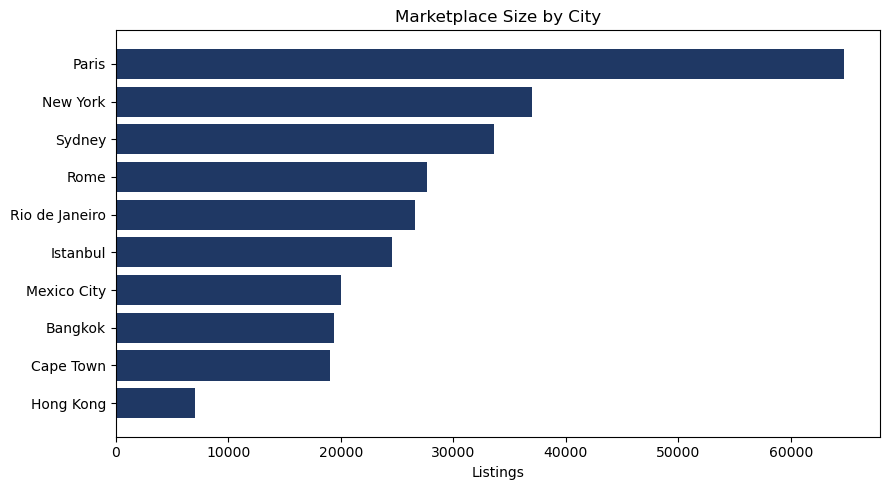

In [5]:
fig, ax = plt.subplots(figsize=(9,5))
ax.barh(city_size['city'][::-1], city_size['listing_count'][::-1], color='#1F3864')
ax.set_xlabel('Listings')
ax.set_title('Marketplace Size by City')
plt.tight_layout()
plt.show()


The visualization highlights a strong concentration of Airbnb listings in a few major global cities. **Paris** leads the marketplace with nearly **65,000 listings**, followed by **New York** and **Sydney**, while **Hong Kong** has the smallest inventory among the analyzed cities.

In [6]:
q1_neigh = """
SELECT city, neighbourhood, COUNT(*) AS listing_count
FROM listings
GROUP BY city, neighbourhood
ORDER BY listing_count DESC
LIMIT 15;
"""
neigh_size = pd.read_sql(q1_neigh, conn)
neigh_size


,city,neighbourhood,listing_count
0,Rome,I Centro Storico,14874
1,Sydney,Sydney,8074
2,Rio de Janeiro,Copacabana,7712
3,Mexico City,Cuauhtemoc,7626
4,Paris,Buttes-Montmartre,7237
5,Istanbul,Beyoglu,6674
6,Paris,Popincourt,6206
7,Paris,Vaugirard,4826
8,Sydney,Waverley,4737
9,Paris,Enclos-St-Laurent,4628


### Business Insight

The neighbourhood-level analysis reveals that Airbnb supply is concentrated within a few high-demand urban districts. **I Centro Storico (Rome)** is the largest neighbourhood marketplace with **14,874 listings**, while **Paris** dominates the rankings with multiple neighbourhoods appearing in the Top 15. This concentration suggests that listing inventory is clustered around major tourist and commercial areas, providing valuable insights for localized pricing strategies, host acquisition initiatives, and demand forecasting.

In [7]:
# Top neighbourhood WITHIN each city (one row per city)
q1_top_per_city = """
SELECT city, neighbourhood, listing_count FROM (
    SELECT city, neighbourhood, COUNT(*) AS listing_count,
           ROW_NUMBER() OVER (PARTITION BY city ORDER BY COUNT(*) DESC) AS rn
    FROM listings
    GROUP BY city, neighbourhood
)
WHERE rn = 1
ORDER BY listing_count DESC;
"""
pd.read_sql(q1_top_per_city, conn)


,city,neighbourhood,listing_count
0,Rome,I Centro Storico,14874
1,Sydney,Sydney,8074
2,Rio de Janeiro,Copacabana,7712
3,Mexico City,Cuauhtemoc,7626
4,Paris,Buttes-Montmartre,7237
5,Istanbul,Beyoglu,6674
6,Cape Town,Ward 115,3293
7,Hong Kong,Yau Tsim Mong,3038
8,New York,Williamsburg,2733
9,Bangkok,Vadhana,2455


### Business Insight

This analysis identifies the **largest Airbnb neighbourhood within each city**, providing a localized view of marketplace concentration. **I Centro Storico (Rome)** leads with **14,874 listings**, followed by **Sydney (Sydney)** and **Copacabana (Rio de Janeiro)**. These neighbourhoods represent the primary supply hubs in their respective cities and are ideal candidates for localized pricing strategies, host engagement programs, and market expansion initiatives. Using `ROW_NUMBER()` ensures that only the highest-performing neighbourhood from each city is selected, making cross-city comparisons straightforward and actionable.

## 2. Which markets generate the highest customer demand based on review activity?
Review count is the standard Airbnb proxy for bookings/demand.

In [8]:
q2 = """
SELECT l.city,
       COUNT(r.review_id)              AS total_reviews,
       COUNT(DISTINCT l.listing_id)     AS n_listings,
       ROUND(1.0 * COUNT(r.review_id) / COUNT(DISTINCT l.listing_id), 2) AS avg_reviews_per_listing
FROM listings l
LEFT JOIN reviews r ON l.listing_id = r.listing_id
GROUP BY l.city
ORDER BY total_reviews DESC;
"""
demand_by_city = pd.read_sql(q2, conn)
demand_by_city


,city,total_reviews,n_listings,avg_reviews_per_listing
0,Paris,1213727,64690,18.76
1,Rome,1113360,27647,40.27
2,New York,847727,37012,22.90
3,Sydney,482552,33630,14.35
4,Mexico City,477584,20065,23.80
5,Rio de Janeiro,323274,26615,12.15
6,Cape Town,302336,19086,15.84
7,Bangkok,284342,19361,14.69
8,Istanbul,194013,24519,7.91
9,Hong Kong,134228,7087,18.94


### Business Insight

Review activity indicates that **Paris** generates the highest overall customer demand with more than **1.2 million reviews**, largely driven by its extensive listing inventory. However, **Rome** stands out with the highest **average reviews per listing (40.27)**, suggesting that its listings experience significantly stronger guest activity on a per-property basis. This highlights the importance of evaluating both total demand and demand intensity when comparing market performance, as cities with fewer listings may achieve higher utilization than larger marketplaces.

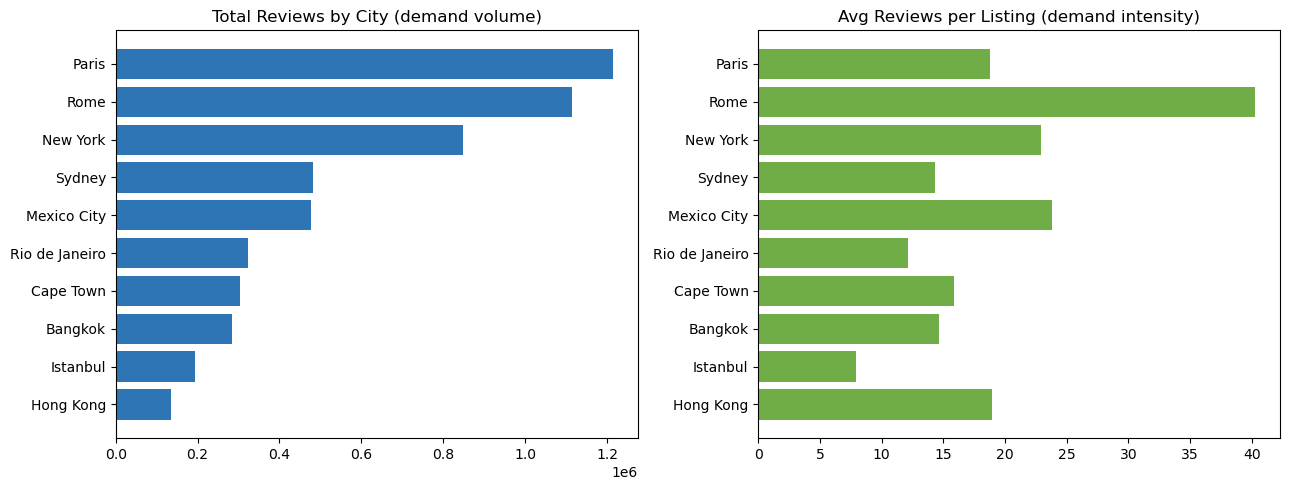

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))
axes[0].barh(demand_by_city['city'][::-1], demand_by_city['total_reviews'][::-1], color='#2E75B6')
axes[0].set_title('Total Reviews by City (demand volume)')
axes[1].barh(demand_by_city['city'][::-1], demand_by_city['avg_reviews_per_listing'][::-1], color='#70AD47')
axes[1].set_title('Avg Reviews per Listing (demand intensity)')
plt.tight_layout()
plt.show()


The two visualizations distinguish between **market size** and **market efficiency**. **Paris** records the highest overall demand with more than **1.2 million reviews**, reflecting its large Airbnb inventory. However, **Rome** achieves the highest **average reviews per listing (40.27)**, indicating stronger guest activity and listing utilization on a per-property basis. This comparison highlights that larger markets do not always generate the highest demand per listing, making both metrics essential for evaluating market performance and identifying high-opportunity cities.

## 3. How do property type, room type, and accommodation capacity influence pricing?
Prices compared **within each city** (not across cities, since price is in local currency).
`price_per_guest` normalizes for accommodation capacity.

In [10]:
q3_room = """
SELECT city, room_type,
       COUNT(*) AS n_listings,
       ROUND(AVG(price), 1) AS avg_price,
       ROUND(AVG(1.0*price/accommodates), 1) AS avg_price_per_guest
FROM listings
WHERE price > 0 AND accommodates > 0
GROUP BY city, room_type
ORDER BY city,
         CASE room_type
             WHEN 'Entire place' THEN 1
             WHEN 'Private room' THEN 2
             WHEN 'Hotel room'   THEN 3
             WHEN 'Shared room'  THEN 4
             ELSE 5 END;
"""
price_by_room = pd.read_sql(q3_room, conn)
price_by_room


,city,room_type,n_listings,avg_price,avg_price_per_guest
0,Bangkok,Entire place,10623,2155.6,668.4
1,Bangkok,Private room,6993,2037.3,822.6
2,Bangkok,Hotel room,1019,2092.8,854.4
3,Bangkok,Shared room,725,1323.1,569.5
4,Cape Town,Entire place,14150,2815.6,547.3
5,Cape Town,Private room,4503,1133.5,517.4
6,Cape Town,Hotel room,306,2929.8,1221.4
7,Cape Town,Shared room,127,499.3,225.9
8,Hong Kong,Entire place,2589,1016.6,330.8
9,Hong Kong,Private room,3888,570.0,284.4


### Business Insight

Comparing room types within each city shows that **Entire Places** generally command the highest average prices due to their larger size and privacy, while **Private Rooms** and **Shared Rooms** are more affordable alternatives. However, the **Average Price per Guest** provides a fairer measure of value by accounting for accommodation capacity. In several cities, larger properties have higher total prices but lower costs per guest, highlighting that listing capacity plays a significant role in pricing strategy and perceived customer value.

In [11]:
q3_property = """
SELECT property_type,
       COUNT(*) AS n_listings,
       ROUND(AVG(price), 1) AS avg_price_raw_all_cities
FROM listings
WHERE price > 0
GROUP BY property_type
HAVING COUNT(*) >= 500
ORDER BY n_listings DESC
LIMIT 15;
"""
pd.read_sql(q3_property, conn)


,property_type,n_listings,avg_price_raw_all_cities
0,Entire apartment,138989,427.1
1,Private room in apartment,47322,276.8
2,Private room in house,13292,438.8
3,Entire house,13273,1880.2
4,Entire condominium,11250,886.5
5,Room in boutique hotel,5705,947.2
6,Entire loft,4587,507.3
7,Private room in condominium,4462,754.3
8,Private room in bed and breakfast,4238,824.7
9,Entire serviced apartment,3973,1250.2


### Business Insight

The analysis shows that **Entire Apartments** dominate Airbnb's inventory with nearly **139,000 listings**, making them the platform's most common property type. Larger property types such as **Entire Houses**, **Entire Serviced Apartments**, and **Entire Townhouses** generally command higher average prices, reflecting their larger size and capacity. Since prices are reported in each city's local currency, these averages should be interpreted as high-level indicators of pricing patterns rather than direct comparisons across markets.

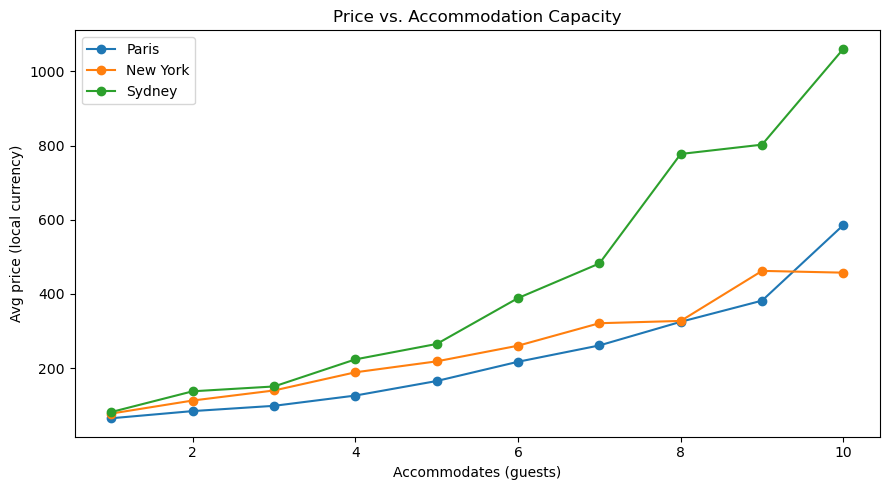

In [12]:
q3_capacity = """
SELECT city, accommodates,
       COUNT(*) AS n_listings,
       ROUND(AVG(price), 1) AS avg_price
FROM listings
WHERE price > 0 AND accommodates BETWEEN 1 AND 10
GROUP BY city, accommodates
ORDER BY city, accommodates;
"""
price_by_capacity = pd.read_sql(q3_capacity, conn)

# Plot the price-vs-capacity curve for a couple of representative cities
fig, ax = plt.subplots(figsize=(9,5))
for city in ["Paris", "New York", "Sydney"]:
    sub = price_by_capacity[price_by_capacity.city == city]
    ax.plot(sub['accommodates'], sub['avg_price'], marker='o', label=city)
ax.set_xlabel('Accommodates (guests)')
ax.set_ylabel('Avg price (local currency)')
ax.set_title('Price vs. Accommodation Capacity')
ax.legend()
plt.tight_layout()
plt.show()


### Business Insight

The analysis shows a clear positive relationship between **accommodation capacity** and **average listing price**, indicating that larger properties generally command higher prices. However, the rate of price growth varies across markets. **Sydney** exhibits the strongest pricing premium for larger-capacity listings, while **New York** shows a more gradual increase that levels off for larger properties. This suggests that customer willingness to pay for additional space differs by market, highlighting the importance of city-specific pricing strategies rather than a one-size-fits-all approach.

## 4. Which hosts consistently outperform others in ratings and responsiveness?
"Consistently" = requires a minimum number of listings (>=3) so a single lucky 5-star listing
doesn't crown a host. Ranked by average rating, then average response rate.

In [13]:
q4 = """
SELECT host_id,
       COUNT(*) AS n_listings,
       ROUND(AVG(review_scores_rating), 1)       AS avg_rating,
       ROUND(AVG(review_scores_communication), 1) AS avg_communication,
       ROUND(AVG(host_response_rate), 3)          AS avg_response_rate,
       ROUND(AVG(host_acceptance_rate), 3)        AS avg_acceptance_rate
FROM listings
WHERE review_scores_rating IS NOT NULL
GROUP BY host_id
HAVING COUNT(*) >= 3
ORDER BY avg_rating DESC, avg_response_rate DESC
LIMIT 20;
"""
top_hosts = pd.read_sql(q4, conn)
top_hosts


,host_id,n_listings,avg_rating,avg_communication,avg_response_rate,avg_acceptance_rate
0,220972,5,100.0,10.0,1.0,0.93
1,464811,3,100.0,9.7,1.0,0.00
2,524550,4,100.0,10.0,1.0,1.00
3,632541,3,100.0,10.0,1.0,0.40
4,926635,3,100.0,10.0,1.0,1.00
5,1106924,3,100.0,10.0,1.0,0.97
6,1667741,3,100.0,10.0,1.0,1.00
7,2138774,4,100.0,10.0,1.0,0.94
8,2320031,3,100.0,10.0,1.0,1.00
9,2464378,3,100.0,10.0,1.0,0.88


### Business Insight

The analysis identifies hosts who consistently deliver exceptional guest experiences by requiring a minimum of **three listings**, reducing the influence of isolated high ratings. The top-performing hosts achieve **perfect average guest ratings (100.0)**, outstanding communication scores, and **100% response rates**, demonstrating that responsiveness and communication are strongly associated with high guest satisfaction. These hosts represent best-practice benchmarks that Airbnb can use to develop host training programs and identify service standards across the platform.

## 5. Do Superhosts deliver better guest experiences than regular hosts?
Compares average review scores (overall + sub-metrics) and host responsiveness/acceptance,
Superhost vs. non-Superhost.

In [14]:
q5 = """
SELECT
    CASE host_is_superhost WHEN 't' THEN 'Superhost' ELSE 'Regular host' END AS host_type,
    COUNT(*)                                    AS n_listings,
    ROUND(AVG(review_scores_rating), 2)         AS avg_overall_rating,
    ROUND(AVG(review_scores_cleanliness), 2)    AS avg_cleanliness,
    ROUND(AVG(review_scores_communication), 2)  AS avg_communication,
    ROUND(AVG(review_scores_checkin), 2)        AS avg_checkin,
    ROUND(AVG(host_response_rate), 3)           AS avg_response_rate,
    ROUND(AVG(host_acceptance_rate), 3)         AS avg_acceptance_rate
FROM listings
WHERE host_is_superhost IN ('t','f')
GROUP BY host_is_superhost;
"""
superhost_compare = pd.read_sql(q5, conn)
superhost_compare


,host_type,n_listings,avg_overall_rating,avg_cleanliness,avg_communication,avg_checkin,avg_response_rate,avg_acceptance_rate
0,Regular host,229294,92.26,9.17,9.62,9.63,0.829,0.795
1,Superhost,50253,97.00,9.75,9.93,9.92,0.966,0.909


### Business Insight

The comparison shows that **Superhosts consistently outperform Regular Hosts across every service quality metric**. Superhosts achieve higher **overall guest ratings (97.00 vs. 92.26)**, better cleanliness, communication, and check-in scores, while also maintaining significantly higher **response rates (96.6% vs. 82.9%)** and **acceptance rates (90.9% vs. 79.5%)**. These findings suggest that the Superhost badge is a strong indicator of superior host performance and guest experience, reinforcing its value as a trusted quality signal for both guests and Airbnb.

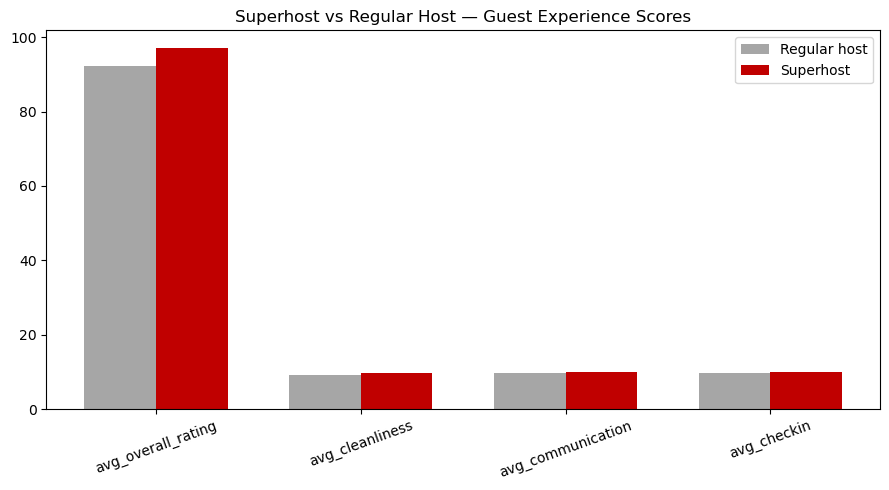

In [15]:
metrics = ['avg_overall_rating','avg_cleanliness','avg_communication','avg_checkin']
fig, ax = plt.subplots(figsize=(9,5))
x = range(len(metrics))
width = 0.35
regular = superhost_compare[superhost_compare.host_type=='Regular host'][metrics].values[0]
super_  = superhost_compare[superhost_compare.host_type=='Superhost'][metrics].values[0]
ax.bar([i-width/2 for i in x], regular, width, label='Regular host', color='#A6A6A6')
ax.bar([i+width/2 for i in x], super_,  width, label='Superhost',   color='#C00000')
ax.set_xticks(list(x)); ax.set_xticklabels(metrics, rotation=20)
ax.set_title('Superhost vs Regular Host — Guest Experience Scores')
ax.legend()
plt.tight_layout()
plt.show()


The grouped comparison shows that **Superhosts consistently outperform Regular Hosts across every guest experience metric**. The largest improvement is observed in **overall guest ratings**, while cleanliness, communication, and check-in scores also remain consistently higher. This visual evidence reinforces that the **Superhost badge represents measurable service excellence**, suggesting that Airbnb's Superhost criteria effectively identify hosts who deliver a superior guest experience.

## 6. How does host experience influence listing performance?
Host experience = tenure on the platform (`host_since` to the dataset's latest observed date).
Bands: <1 year, 1-3 years, 3-5 years, 5+ years.

In [16]:
q6 = """
SELECT
    CASE
        WHEN (julianday((SELECT MAX(date) FROM reviews)) - julianday(host_since)) / 365.0 < 1 THEN '0. <1 year'
        WHEN (julianday((SELECT MAX(date) FROM reviews)) - julianday(host_since)) / 365.0 < 3 THEN '1. 1-3 years'
        WHEN (julianday((SELECT MAX(date) FROM reviews)) - julianday(host_since)) / 365.0 < 5 THEN '2. 3-5 years'
        ELSE '3. 5+ years'
    END AS host_tenure_band,
    COUNT(*)                                     AS n_listings,
    ROUND(AVG(review_scores_rating), 2)          AS avg_rating,
    ROUND(AVG(host_response_rate), 3)            AS avg_response_rate,
    ROUND(100.0 * SUM(CASE WHEN host_is_superhost='t' THEN 1 ELSE 0 END) / COUNT(*), 1) AS pct_superhost
FROM listings
WHERE host_since IS NOT NULL
GROUP BY host_tenure_band
ORDER BY host_tenure_band;
"""
host_tenure = pd.read_sql(q6, conn)
host_tenure


,host_tenure_band,n_listings,avg_rating,avg_response_rate,pct_superhost
0,0. <1 year,13323,90.48,0.859,7.5
1,1. 1-3 years,59137,92.05,0.821,16.6
2,2. 3-5 years,65038,93.53,0.870,18.0
3,3. 5+ years,142049,93.96,0.886,19.5


### Business Insight

This analysis explores whether **host experience translates into better listing performance** by grouping hosts based on their tenure on the Airbnb platform. Comparing guest ratings, response rates, and the percentage of Superhosts across experience bands helps determine whether longer-tenured hosts consistently deliver higher service quality. These insights can guide Airbnb's host onboarding, training programs, and retention strategies by identifying how experience influences host performance.

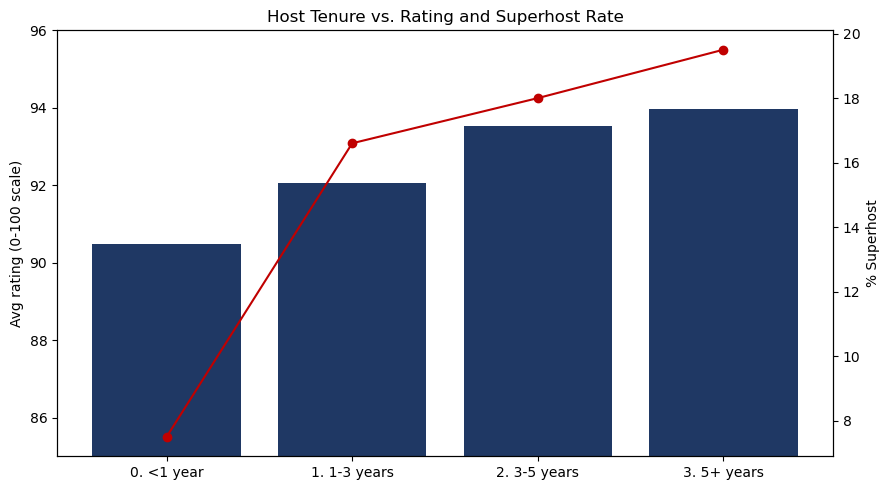

In [17]:
fig, ax1 = plt.subplots(figsize=(9,5))
ax1.bar(host_tenure['host_tenure_band'], host_tenure['avg_rating'], color='#1F3864')
ax1.set_ylabel('Avg rating (0-100 scale)')
ax1.set_ylim(85, 96)
ax2 = ax1.twinx()
ax2.plot(host_tenure['host_tenure_band'], host_tenure['pct_superhost'], color='#C00000', marker='o')
ax2.set_ylabel('% Superhost')
ax1.set_title('Host Tenure vs. Rating and Superhost Rate')
plt.tight_layout()
plt.show()


The visualization shows a clear positive relationship between **host experience** and **listing performance**. As host tenure increases, **average guest ratings** steadily improve, while the **percentage of Superhosts** also rises substantially. Hosts with **5+ years of experience** achieve the highest ratings and the greatest concentration of Superhosts, suggesting that experience, operational knowledge, and sustained platform engagement contribute to consistently better guest experiences and higher service quality.

## 7. Which listings are significantly overpriced or underpriced compared to local market averages?
"Local market" = same city + same room type. A listing is flagged if its price is 50%+ above/below
that market average (threshold is adjustable).

In [18]:
THRESHOLD_PCT = 50  # flag listings +/- this % vs local market average

q7 = f"""
WITH market_avg AS (
    SELECT city, room_type, AVG(price) AS avg_market_price
    FROM listings
    WHERE price > 0
    GROUP BY city, room_type
)
SELECT l.listing_id, l.city, l.neighbourhood, l.room_type, l.property_type, l.price,
       ROUND(m.avg_market_price, 1) AS market_avg_price,
       ROUND(100.0 * (l.price - m.avg_market_price) / m.avg_market_price, 1) AS pct_diff_vs_market
FROM listings l
JOIN market_avg m ON l.city = m.city AND l.room_type = m.room_type
WHERE l.price > 0
  AND ABS(100.0 * (l.price - m.avg_market_price) / m.avg_market_price) >= {THRESHOLD_PCT}
ORDER BY pct_diff_vs_market DESC;
"""
mispriced = pd.read_sql(q7, conn)
print(f"{len(mispriced):,} listings flagged as 50%+ above/below their local market average")
mispriced.head(10)  # most overpriced


134,550 listings flagged as 50%+ above/below their local market average


,listing_id,city,neighbourhood,room_type,property_type,price,market_avg_price,pct_diff_vs_market
0,47885441,Mexico City,Cuauhtemoc,Private room,Room in boutique hotel,499000,795.9,62598.8
1,14658972,Istanbul,Fatih,Private room,Private room in bed and breakfast,179532,405.9,44131.7
2,16111771,Istanbul,Fatih,Private room,Room in boutique hotel,179532,405.9,44131.7
3,16111705,Istanbul,Fatih,Private room,Room in boutique hotel,179532,405.9,44131.7
4,16401723,Istanbul,Fatih,Private room,Room in boutique hotel,179153,405.9,44038.3
5,23895520,Mexico City,Iztapalapa,Private room,Private room in house,350000,795.9,43877.1
6,13879989,Rio de Janeiro,Sao Cristovao,Shared room,Shared room in house,625216,1456.7,42818.9
7,45537032,Istanbul,Fatih,Private room,Private room in bed and breakfast,148441,405.9,36471.8
8,39212507,Rio de Janeiro,Copacabana,Private room,Private room in bed and breakfast,134562,448.3,29915.0
9,39096468,Rio de Janeiro,Copacabana,Private room,Private room in bed and breakfast,126233,448.3,28057.2


### Business Insight

Using a **±50% threshold** relative to the average price of listings with the **same city and room type**, the analysis flagged **134,550 listings** as potential pricing outliers. Several of the most extreme cases exceed their local market averages by tens of thousands of percent, strongly suggesting **data quality issues** such as incorrect price entries or currency formatting errors rather than genuine market behavior. These listings should be reviewed before performing pricing optimization or revenue analysis, as they could significantly distort market benchmarks and business decisions.

In [19]:
mispriced.tail(10)  # most underpriced (most negative pct_diff_vs_market)


,listing_id,city,neighbourhood,room_type,property_type,price,market_avg_price,pct_diff_vs_market
134540,5212620,Rio de Janeiro,Leme,Shared room,Shared room in house,40,1456.7,-97.3
134541,5212678,Rio de Janeiro,Copacabana,Shared room,Shared room in house,40,1456.7,-97.3
134542,4858341,Rio de Janeiro,Leme,Shared room,Shared room in house,40,1456.7,-97.3
134543,13550430,Rio de Janeiro,Maria da Graca,Shared room,Shared room in house,40,1456.7,-97.3
134544,27516781,Rio de Janeiro,Quintino Bocaiuva,Shared room,Shared room in house,40,1456.7,-97.3
134545,936180,Rio de Janeiro,Gamboa,Shared room,Shared room in house,39,1456.7,-97.3
134546,27575768,Rio de Janeiro,Gavea,Shared room,Shared room in house,37,1456.7,-97.5
134547,9651430,Rio de Janeiro,Vila Isabel,Shared room,Shared room in house,35,1456.7,-97.6
134548,42665426,Rio de Janeiro,Tijuca,Shared room,Shared room in house,34,1456.7,-97.7
134549,43345284,Hong Kong,Sai Kung,Entire place,Tent,1,1016.6,-99.9


### Business Insight

The lowest-priced listings are concentrated almost entirely in **Rio de Janeiro**, where several shared rooms are priced **over 97% below** the average price of comparable listings. The most extreme case is a **Hong Kong tent** listed for **1 unit of local currency**, nearly **100% below** its local market average. While some of these listings may represent aggressive pricing strategies, the magnitude of the differences strongly suggests potential **data entry errors, promotional pricing, or unusual property characteristics**. These listings should be reviewed before using the data for pricing optimization or revenue forecasting.

In [20]:
print("Overpriced vs underpriced split:")
print(f"  Overpriced (>= +{THRESHOLD_PCT}%): {(mispriced.pct_diff_vs_market > 0).sum():,}")
print(f"  Underpriced (<= -{THRESHOLD_PCT}%): {(mispriced.pct_diff_vs_market < 0).sum():,}")
print(f"  Total flagged: {len(mispriced):,} out of {pd.read_sql('SELECT COUNT(*) c FROM listings WHERE price>0', conn).c[0]:,} priced listings ({len(mispriced)/pd.read_sql('SELECT COUNT(*) c FROM listings WHERE price>0', conn).c[0]*100:.1f}%)")


Overpriced vs underpriced split:
  Overpriced (>= +50%): 31,225
  Underpriced (<= -50%): 103,325
  Total flagged: 134,550 out of 279,599 priced listings (48.1%)


### Business Insight

The pricing anomaly analysis flagged **134,550 listings (48.1% of all priced listings)** as deviating by at least **±50%** from the average price of comparable listings in the same city and room type. Notably, **underpriced listings (103,325)** outnumber **overpriced listings (31,225)** by more than **3 to 1**, suggesting that aggressive discounting, promotional pricing, or data quality issues are more prevalent than excessive pricing. These findings highlight the need for targeted pricing reviews and stronger validation rules to improve marketplace pricing consistency.

## 8. What seasonal trends exist in customer reviews and booking activity?
Review dates are used as a proxy for guest stays/booking activity. We look at monthly seasonality
(pooled across all years) and the year-over-year trend.

In [21]:
q8_month = """
SELECT CAST(strftime('%m', date) AS INTEGER) AS month, COUNT(*) AS review_count
FROM reviews
GROUP BY month
ORDER BY month;
"""
seasonality = pd.read_sql(q8_month, conn)
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
seasonality['month_name'] = seasonality['month'].apply(lambda m: month_names[m-1])
seasonality


,month,review_count,month_name
0,1,496802,Jan
1,2,408320,Feb
2,3,401732,Mar
3,4,375740,Apr
4,5,398185,May
5,6,426258,Jun
6,7,456495,Jul
7,8,441171,Aug
8,9,511245,Sep
9,10,552877,Oct


### Business Insight

Monthly review activity reveals clear seasonal demand patterns across the Airbnb marketplace. **October** records the highest review volume (**552,877 reviews**), followed by **September** and **January**, indicating periods of elevated guest activity. In contrast, **April** experiences the lowest review count, suggesting comparatively weaker demand. These recurring seasonal trends can help Airbnb and hosts optimize pricing, marketing campaigns, staffing, and inventory planning during peak and off-peak periods.

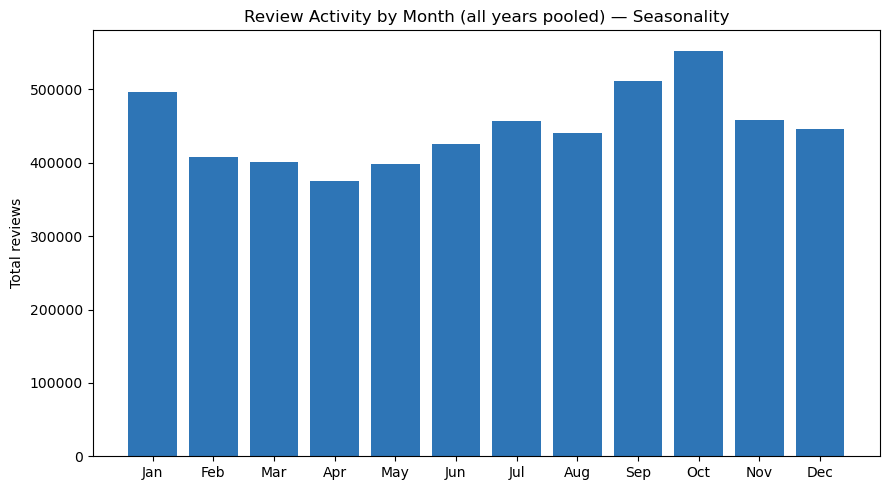

In [22]:
fig, ax = plt.subplots(figsize=(9,5))
ax.bar(seasonality['month_name'], seasonality['review_count'], color='#2E75B6')
ax.set_title('Review Activity by Month (all years pooled) — Seasonality')
ax.set_ylabel('Total reviews')
plt.tight_layout()
plt.show()


The chart highlights clear **seasonal demand patterns** across the Airbnb marketplace. Review activity gradually increases through the middle of the year, peaks in **October (552,877 reviews)**, and remains high during **September** and **January**, indicating periods of stronger guest demand. In contrast, **April records the lowest review activity**, suggesting a seasonal slowdown. These insights can support **dynamic pricing strategies, marketing campaigns, staffing decisions, and host inventory planning** by helping Airbnb anticipate peak and off-peak travel periods.

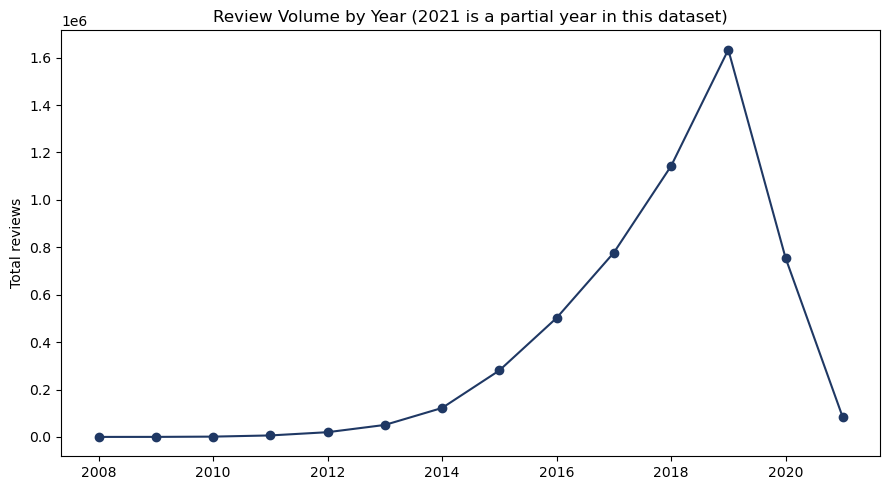

,year,review_count
0,2008,2
1,2009,115
2,2010,1236
3,2011,6253
4,2012,19922
5,2013,50522
6,2014,122132
7,2015,280332
8,2016,501754
9,2017,777200


In [23]:
q8_year = """
SELECT CAST(strftime('%Y', date) AS INTEGER) AS year, COUNT(*) AS review_count
FROM reviews
GROUP BY year
ORDER BY year;
"""
yearly_trend = pd.read_sql(q8_year, conn)

fig, ax = plt.subplots(figsize=(9,5))
ax.plot(yearly_trend['year'], yearly_trend['review_count'], marker='o', color='#1F3864')
ax.set_title('Review Volume by Year (2021 is a partial year in this dataset)')
ax.set_ylabel('Total reviews')
plt.tight_layout()
plt.show()
yearly_trend


### Business Insight

The yearly trend shows **rapid and sustained growth in Airbnb review activity from 2008 to 2019**, with review volume increasing from just **2 reviews in 2008** to over **1.63 million in 2019**, highlighting the platform's rapid global expansion. A significant decline is observed in **2020**, consistent with the disruption to global travel during the COVID-19 pandemic. Although **2021** appears much lower, it represents **only a partial year** in the dataset and should not be directly compared with previous full years. Overall, the analysis demonstrates both Airbnb's long-term marketplace growth and the impact of major external events on customer demand.

## 9. Which neighbourhoods contribute the largest share of marketplace demand? (Pareto analysis)
Demand = total reviews per neighbourhood. Run per city (change `TARGET_CITY` below) since
neighbourhood sets are city-specific and not comparable across cities.

In [24]:
TARGET_CITY = "Paris"  # change to any of the 10 cities

q9 = f"""
WITH neigh_reviews AS (
    SELECT l.neighbourhood, COUNT(r.review_id) AS n_reviews
    FROM listings l
    LEFT JOIN reviews r ON l.listing_id = r.listing_id
    WHERE l.city = '{TARGET_CITY}'
    GROUP BY l.neighbourhood
),
ranked AS (
    SELECT *,
           SUM(n_reviews) OVER ()                                   AS total_reviews,
           ROW_NUMBER() OVER (ORDER BY n_reviews DESC)              AS rn
    FROM neigh_reviews
)
SELECT neighbourhood, n_reviews,
       ROUND(100.0 * n_reviews / total_reviews, 2) AS pct_of_city_demand,
       ROUND(100.0 * SUM(n_reviews) OVER (ORDER BY n_reviews DESC) / total_reviews, 2) AS cumulative_pct
FROM ranked
ORDER BY n_reviews DESC;
"""
pareto = pd.read_sql(q9, conn)
pareto.head(15)


,neighbourhood,n_reviews,pct_of_city_demand,cumulative_pct
0,Buttes-Montmartre,118379,9.75,9.75
1,Popincourt,113523,9.35,19.11
2,Enclos-St-Laurent,93483,7.70,26.81
3,Vaugirard,86206,7.10,33.91
4,Temple,77632,6.40,40.31
5,Bourse,64145,5.28,45.59
6,Opera,61589,5.07,50.67
7,Batignolles-Monceau,57948,4.77,55.44
8,Hotel-de-Ville,54818,4.52,59.96
9,Buttes-Chaumont,51282,4.23,64.18


### Business Insight

The Pareto analysis shows that customer demand in **Paris is highly concentrated across a relatively small number of neighbourhoods**. **Buttes-Montmartre** alone contributes **9.75%** of all reviews, while the **top 14 neighbourhoods collectively account for over 80% of total marketplace demand**. This concentration suggests that Airbnb should prioritize pricing strategies, marketing efforts, host acquisition, and operational support in these high-demand neighbourhoods, where improvements are likely to have the greatest business impact.

Paris: 14 of 20 neighbourhoods (70%) generate ~80% of review demand


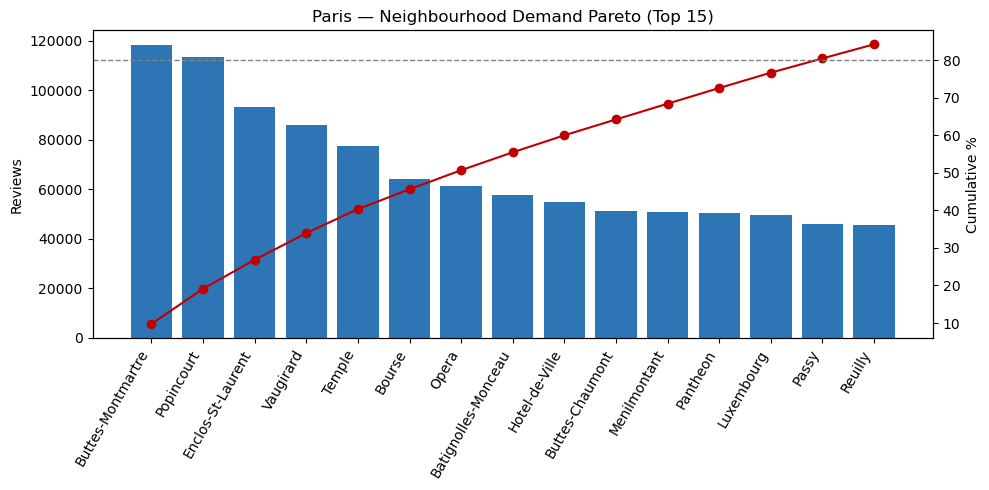

In [25]:
# How many neighbourhoods drive 80% of demand? (classic Pareto cut)
n_80pct = (pareto['cumulative_pct'] <= 80).sum() + 1
print(f"{TARGET_CITY}: {n_80pct} of {len(pareto)} neighbourhoods ({n_80pct/len(pareto)*100:.0f}%) generate ~80% of review demand")

fig, ax1 = plt.subplots(figsize=(10,5))
top = pareto.head(15)
ax1.bar(top['neighbourhood'], top['n_reviews'], color='#2E75B6')
ax1.set_ylabel('Reviews')
plt.xticks(rotation=60, ha='right')
ax2 = ax1.twinx()
ax2.plot(top['neighbourhood'], top['cumulative_pct'], color='#C00000', marker='o')
ax2.axhline(80, color='gray', linestyle='--', linewidth=1)
ax2.set_ylabel('Cumulative %')
ax1.set_title(f'{TARGET_CITY} — Neighbourhood Demand Pareto (Top 15)')
plt.tight_layout()
plt.show()


The Pareto analysis reveals that **customer demand in Paris is concentrated within a relatively small group of neighbourhoods**. Specifically, **14 out of 20 neighbourhoods (70%) generate approximately 80% of all review activity**, with **Buttes-Montmartre**, **Popincourt**, and **Enclos-St-Laurent** contributing the largest shares. This concentration suggests that Airbnb can maximize business impact by prioritizing pricing optimization, marketing initiatives, host acquisition, and operational support in these high-demand neighbourhoods while using lower-demand areas as opportunities for targeted marketplace growth.

## 10. What KPIs should executives monitor to evaluate marketplace health?
A single-query KPI snapshot covering supply, demand, quality, and host-health metrics, followed
by the same KPIs broken out by city so leadership can compare markets at a glance.

In [26]:
q10_overall = """
SELECT
    (SELECT COUNT(*) FROM listings)                                                    AS total_listings,
    (SELECT COUNT(DISTINCT host_id) FROM listings)                                     AS total_hosts,
    (SELECT COUNT(*) FROM reviews)                                                     AS total_reviews,
    ROUND((SELECT AVG(review_scores_rating) FROM listings WHERE review_scores_rating IS NOT NULL), 2)     AS avg_platform_rating,
    ROUND(100.0 * (SELECT COUNT(*) FROM listings WHERE host_is_superhost='t') /
                  (SELECT COUNT(*) FROM listings WHERE host_is_superhost IN ('t','f')), 2)                AS pct_superhost,
    ROUND(100.0 * (SELECT COUNT(*) FROM listings WHERE instant_bookable='t') /
                  (SELECT COUNT(*) FROM listings), 2)                                                     AS pct_instant_bookable,
    ROUND(100.0 * (SELECT COUNT(*) FROM listings l WHERE EXISTS (SELECT 1 FROM review_counts rc WHERE rc.listing_id=l.listing_id)) /
                  (SELECT COUNT(*) FROM listings), 2)                                                      AS pct_listings_with_reviews
;
"""
kpi_overall = pd.read_sql(q10_overall, conn)
kpi_overall.T.rename(columns={0:'value'})


,value
total_listings,279712.00
total_hosts,182024.00
total_reviews,5373143.00
avg_platform_rating,93.41
pct_superhost,17.98
pct_instant_bookable,41.33
pct_listings_with_reviews,69.20


### Business Insight

The executive KPI snapshot indicates a **large, healthy, and highly engaged Airbnb marketplace** with **279,712 listings**, **182,024 hosts**, and more than **5.37 million customer reviews**. An average guest rating of **93.41** reflects strong overall customer satisfaction, while **17.98% of listings are managed by Superhosts**, reinforcing a solid base of high-quality hosts. Additionally, **41.33% of listings support Instant Booking**, improving booking convenience, and **69.20% of listings have received at least one review**, suggesting that most properties have established customer trust and marketplace activity. Together, these KPIs provide executives with a concise view of marketplace scale, demand, service quality, and operational health.

In [27]:
q10_by_city = """
SELECT l.city,
       COUNT(DISTINCT l.listing_id)                                                     AS total_listings,
       COUNT(DISTINCT l.host_id)                                                        AS total_hosts,
       ROUND(AVG(l.review_scores_rating), 2)                                            AS avg_rating,
       ROUND(100.0 * SUM(CASE WHEN l.host_is_superhost='t' THEN 1 ELSE 0 END) /
                     SUM(CASE WHEN l.host_is_superhost IN ('t','f') THEN 1 ELSE 0 END), 1) AS pct_superhost,
       ROUND(100.0 * SUM(CASE WHEN l.instant_bookable='t' THEN 1 ELSE 0 END) / COUNT(*), 1) AS pct_instant_bookable,
       ROUND(AVG(rc.n_reviews), 1)                                                       AS avg_reviews_per_listing
FROM listings l
LEFT JOIN review_counts rc ON l.listing_id = rc.listing_id
GROUP BY l.city
ORDER BY total_listings DESC;
"""
kpi_by_city = pd.read_sql(q10_by_city, conn)
kpi_by_city


,city,total_listings,total_hosts,avg_rating,pct_superhost,pct_instant_bookable,avg_reviews_per_listing
0,Paris,64690,51955,93.06,12.5,31.9,24.7
1,New York,37012,26765,93.77,18.8,29.8,30.8
2,Sydney,33630,24965,93.23,12.1,37.5,20.4
3,Rome,27647,14592,93.52,25.9,57.9,52.5
4,Rio de Janeiro,26615,17324,94.57,17.1,34.4,19.4
5,Istanbul,24519,13566,91.06,13.2,55.4,16.6
6,Mexico City,20065,11527,94.84,31.9,51.1,32.5
7,Bangkok,19361,8327,93.00,20.1,60.1,24.9
8,Cape Town,19086,11118,94.40,24.1,43.1,22.0
9,Hong Kong,7087,2048,89.71,18.2,34.7,34.7


### Business Insight

The city-level KPI comparison highlights meaningful differences in marketplace performance across Airbnb markets. **Paris** leads in marketplace size with the highest number of listings, **Rome** demonstrates the strongest customer engagement with the highest average reviews per listing, **Mexico City** achieves both the highest average guest rating and the largest share of Superhosts, while **Bangkok** leads in Instant Booking adoption. Conversely, **Hong Kong** has the smallest marketplace and the lowest average guest rating, indicating potential opportunities for service quality improvements. Together, these KPIs enable executives to benchmark markets, identify best-performing cities, and prioritize operational improvements based on data rather than relying on a single performance metric.

### Recommended executive KPI set (based on the fields above)
| KPI | Why it matters |
|---|---|
| **Total active listings** (supply) | Marketplace scale & growth trend |
| **Total hosts** & listings-per-host | Host concentration risk (are a few professional hosts dominating?) |
| **Reviews per listing / total reviews** (demand proxy) | Guest demand & booking activity trend |
| **% listings with zero reviews** | "Cold start" / inactive supply — a health risk if rising |
| **Average platform rating** | Overall guest satisfaction |
| **% Superhost** | Host quality & program health |
| **% Instant bookable** | Booking friction / conversion-rate driver |
| **% listings flagged over/underpriced** (Q7) | Pricing-guidance / marketplace-trust risk |
| **Neighbourhood concentration (Pareto, Q9)** | Demand concentration risk — over-reliance on a few hotspots |
| **YoY review growth** (Q8) | Leading indicator of marketplace momentum |

These blend supply, demand, quality, and risk signals — the standard lens for a marketplace-health
dashboard — rather than any single metric in isolation.


## Wrap-up
Close the connection when done exploring.

In [28]:
conn.close()
